In [ ]:
import os
import polars as pl
import json
from tqdm import tqdm

from etytreealg.decode import langcodes as langcodes
from etytreealg.utils.notebook_io import hydrate_df, load_df
from etytreealg.decode.decode_templates import get_langcodes_and_words
from etytreealg.decode.decode_words import decode_word

In [2]:
import importlib
importlib.reload(langcodes)
from etytreealg.utils import notebook_io
importlib.reload(notebook_io)
from etytreealg.decode import decode_templates
importlib.reload(decode_templates)
from etytreealg.decode import decode_words
importlib.reload(decode_words)


<module 'etytreealg.decode.decode_words' from 'C:\\conjunct\\etytreealg\\etytreealg\\decode\\decode_words.py'>

In [3]:
df = load_df()
df = df.with_row_index("index")

In [4]:
df = hydrate_df(df)

Hydrated!


In [26]:
english_df = df.filter(pl.col("lang") == "English")
english_df

index,word,lang,lang_code,ety,etymology_number,num_templates,forms_of,templates_h,related_h,descendants_h
u32,str,str,str,str,u8,u32,list[str],object,object,object
1,"""apples and pears""","""English""","""en""",null,0,0,null,null,null,null
2,"""abhal""","""English""","""en""","""From Arabic أَبْهَل (ʔabhal).""",0,1,null,"[{'name': 'der', 'args': {'1': 'en', '2': 'ar', '3': 'أَبْهَل'}, 'expansion': 'Arabic أَبْهَل (ʔabhal)'}]",null,null
3,"""abaisance""","""English""","""en""","""From Old French abaissance.""",0,1,null,"[{'name': 'der', 'args': {'1': 'en', '2': 'fro', '3': 'abaissance'}, 'expansion': 'Old French abaissance'}]",null,null
4,"""A 1""","""English""","""en""",null,0,0,null,null,null,null
5,"""abeyancy""","""English""","""en""","""abeyance + -y""",0,1,null,"[{'name': 'suffix', 'args': {'1': 'en', '2': 'abeyance', '3': 'y'}, 'expansion': 'abeyance + -y'}]",null,null
…,…,…,…,…,…,…,…,…,…,…
9633550,"""copulate with""","""English""","""en""",null,0,0,null,null,null,null
9633551,"""physical property""","""English""","""en""",null,0,0,null,null,null,null
9633552,"""unit of measure""","""English""","""en""",null,0,0,null,null,null,null


In [7]:
spanish_df = df.filter(
    (pl.col("lang") == "Spanish")
)

In [ ]:
from tqdm import tqdm

from etytreealg.decode.decode_words import decode_word
from etytreealg.graph.graph_construct import most_common_referenced_languages


In [68]:
spanish_freqs = most_common_referenced_languages(spanish_df, "es", hreadable=True, need_subset=False)

100%|██████████| 784095/784095 [00:01<00:00, 577330.84it/s]


In [69]:
spanish_freqs

{'Latin': 12792,
 'English': 2768,
 'Old Spanish': 2636,
 'Ancient Greek': 2073,
 'French': 1885,
 'Late Latin': 1249,
 'Italian': 992,
 'Portuguese': 979,
 'Vulgar Latin': 923,
 'Proto-Indo-European': 886,
 'Catalan': 663,
 'Arabic': 599,
 'Classical Nahuatl': 457,
 'Medieval Latin': 445,
 'Basque': 345,
 'Galician': 274,
 'Proto-Italic': 255,
 'German': 227,
 'Old French': 225,
 'New Latin': 218,
 'Andalusian Arabic': 214,
 'Quechua': 202,
 'Proto-Germanic': 160,
 'Japanese': 129,
 'Romanian': 126,
 'Occitan': 106,
 'Old Occitan': 95,
 'Tagalog': 83,
 'Dutch': 83,
 'Asturian': 78,
 'Taíno': 76,
 'Hebrew': 74,
 'Frankish': 69,
 'Sanskrit': 64,
 'Germanic': 62,
 'Persian': 54,
 'Ecclesiastical Latin': 51,
 'Old English': 50,
 'Gothic': 49,
 'Proto-Celtic': 48,
 'Pipil': 46,
 'Guanche': 45,
 'Russian': 44,
 'Old High German': 43,
 'Caló': 43,
 'Early Medieval Latin': 42,
 'Guaraní': 42,
 'Nahuan': 40,
 'Aragonese': 39,
 'Sicilian': 37,
 'Mapudungun': 35,
 'Malay': 32,
 'Ladino': 30,
 'O

In [70]:
english_freqs = most_common_referenced_languages(english_df, "en", hreadable=True, need_subset=False)

100%|██████████| 1293970/1293970 [00:05<00:00, 240062.86it/s]


In [71]:
english_freqs

{'Latin': 49502,
 'Middle English': 43751,
 'Old English': 22265,
 'Ancient Greek': 19480,
 'Proto-Indo-European': 19115,
 'French': 16399,
 'German': 14056,
 'Old French': 13248,
 'Proto-Germanic': 9362,
 'Dutch': 7878,
 'Italian': 6187,
 'Spanish': 5925,
 'Swedish': 4373,
 'Middle French': 4204,
 'Proto-West Germanic': 4073,
 'Arabic': 3947,
 'Old Norse': 3920,
 'Danish': 3332,
 'Mandarin': 3198,
 'Scots': 3193,
 'Japanese': 2877,
 'Late Latin': 2761,
 'Irish': 2734,
 'Icelandic': 2724,
 'Sanskrit': 2669,
 'Russian': 2451,
 'West Frisian': 2398,
 'Medieval Latin': 2209,
 'Anglo-Norman': 2121,
 'Norwegian': 1688,
 'Middle Dutch': 1676,
 'Polish': 1652,
 'Low German': 1632,
 'Hebrew': 1551,
 'Saterland Frisian': 1525,
 'Old High German': 1465,
 'Portuguese': 1383,
 'Hindi': 1308,
 'Middle Low German': 1307,
 'Welsh': 1281,
 'New Latin': 1138,
 'Translingual': 1118,
 'Hanyu Pinyin': 1088,
 'German Low German': 1068,
 'Chinese': 1027,
 'Middle High German': 964,
 'Persian': 960,
 'Scotti

In [6]:
target_langs = """Latin
English
Spanish
Old Spanish
Ancient Greek
Late Latin
Medieval Latin
Vulgar Latin
Proto-Indo-European

French
Italian
Portuguese

German
Proto-Germanic
Proto-West Germanic

Middle French
Old French

Middle English
Old English

Arabic
Old Norse""".split("\n")
target_langs = [x for x in target_langs if x]
target_langcodes = "la,en,es,osp,grc,LL.,ML.,VL.,ine-pro,fr,it,pt,de,gem-pro,gmw-pro,frm,fro,enm,ang,ar,non".split(",")

In [98]:
df_orig = load_df()
df_orig = df_orig.with_row_index("index")

In [117]:
df_orig.filter(
    # pl.col('word').str.contains('æ'),
    pl.col('word').str.contains(u'\u012b'),
    pl.col('lang').str.contains('Middle '),
    # pl.col('lang').str.contains('Latin'),
    # pl.col('templates').str.contains('[ĀǢĒĪŌŪ]'),
)

index,word,lang,lang_code,ety,templates,etymology_number,num_templates,related,descendants,forms_of
u32,str,str,str,str,str,u8,u32,str,str,list[str]


In [ ]:
# gloss = df_orig.filter(
#     pl.col('templates').str.contains('<[a-z]+:(.*?)>'),
# )
# gloss

index,word,lang,lang_code,ety,templates,etymology_number,num_templates,related,descendants,forms_of
u32,str,str,str,str,str,u8,u32,str,str,list[str]
680,"""acanthopodious""","""English""","""en""","""From Ancient Greek ἀκανθο- (ak…","""[{""name"": ""af"", ""args"": {""1"": …",0,1,null,null,null
1449,"""millisecond""","""English""","""en""","""milli- + second""","""[{""name"": ""prefix"", ""args"": {""…",0,1,null,null,null
2331,"""pumpkin""","""English""","""en""","""From Middle French pompon, fro…","""[{""name"": ""root"", ""args"": {""1""…",0,9,"""[{""word"": ""calabash""}, {""word""…",null,null
4710,"""paraguas""","""Spanish""","""es""","""Verb-object compound, composed…","""[{""name"": ""es-verb-obj"", ""args…",0,1,"""[{""word"": ""parasol""}]""","""[{""depth"": 1, ""templates"": [{""…","[""paragua""]"
7824,"""outdoors""","""English""","""en""","""From outdoor (adjective) + -s …","""[{""name"": ""suffix"", ""args"": {""…",1,2,"""[{""word"": ""withoutdoors""}]""",null,null
…,…,…,…,…,…,…,…,…,…,…
9632178,"""perfectioniste""","""Dutch""","""nl""","""From perfectionist + -e.""","""[{""name"": ""af"", ""args"": {""1"": …",0,1,null,null,"[""perfectionist""]"
9632337,"""lehimlemek""","""Turkish""","""tr""","""From Ottoman Turkish لهیملمك. …","""[{""name"": ""inh"", ""args"": {""1"":…",0,2,null,null,null
9633252,"""Mahometanus""","""Latin""","""la""","""From Mahomētus (“Muhammad”) + …","""[{""name"": ""suffix"", ""args"": {""…",0,1,null,null,null


In [7]:
target_df = df.filter(
    pl.col("lang").is_in(target_langs) &
    (pl.col("num_templates") > 0)
)
# target_df

In [ ]:
# all_word_set = set(df['word'].unique())

In [8]:
importlib.reload(decode_templates)
from etytreealg.decode.decode_templates import get_langcodes_and_words

In [ ]:
# get_langcodes_and_words('suf', {'1': 'en', '2': 'nourish', '3': 'ment'}, 'en')

(['en'], ['nourish', '-ment'])

In [11]:

import importlib
from etytreealg.graph import graph_construct
importlib.reload(graph_construct)

from etytreealg.graph.graph_construct import construct_edges_df
edges_df = construct_edges_df(target_df)

  0%|          | 0/865420 [00:00<?, ?it/s]

100%|██████████| 865420/865420 [00:42<00:00, 20325.03it/s]


In [80]:
edges_df = pl.read_parquet("../data/parquet/spanish_edges.parquet")

In [81]:
# struct_dtype = pl.Struct([pl.field("source_word", pl.Utf8()), pl.field("source_lang", pl.Utf8())])


edges_df = edges_df.with_columns([
    pl.lit(-1, dtype=pl.Int64).alias("target_ety"),
])
edges_df = edges_df.with_row_index("edge_id")
# .with_columns([
#     pl.struct({"source_word": pl.Utf8, "source_lang": pl.Utf8, "source_ety": pl.Int32}).struct.rename_fields(['word', 'lang', "ety_number"]).alias("source"),
#     pl.struct({"target_word": pl.Utf8, "target_lang": pl.Utf8, "target_ety": pl.Int32}).struct.rename_fields(['word', 'lang', "ety_number"]).alias("target"),
# ])

In [82]:
edges_df

edge_id,source_word,source_lang,source_ety,target_word,target_lang,template_name,target_ety
u32,str,str,i64,str,str,str,i64
0,"""abhal""","""en""",0,"""أَبْهَل""","""ar""","""der""",-1
1,"""abaisance""","""en""",0,"""abaissance""","""fro""","""der""",-1
2,"""abeyancy""","""en""",0,"""abeyance""","""en""","""suffix""",-1
3,"""abeyancy""","""en""",0,"""-y""","""en""","""suffix""",-1
4,"""aberuncator""","""en""",0,"""averruncate""","""en""","""af""",-1
…,…,…,…,…,…,…,…
2048795,"""craftly""","""en""",2,"""craftly""","""enm""","""m""",-1
2048796,"""craftly""","""en""",2,"""creftly""","""enm""","""m""",-1
2048797,"""craftly""","""en""",2,"""cræftlīce""","""ang""","""inh""",-1


In [96]:
vertex_df = (
    pl.concat([
        # edges_df[['source_word', 'source_lang', 'source_ety']]
        #   .rename({"source_word": "word", "source_lang": "lang", "source_ety": "ety_number"}),
        # edges_df[['target_word', 'target_lang', 'target_ety']]
        #   .rename({"target_word": "word", "target_lang": "lang", "target_ety": "ety_number"}),
        edges_df[['source_word', 'source_lang']]
            .rename({"source_word": "word", "source_lang": "lang"}),
        edges_df[['target_word', 'target_lang']]
            .rename({"target_word": "word", "target_lang": "lang"}),
    ]) # .to_frame()
    .unique()
    # .unnest('source')
    .with_row_index("vertex_id")
    # .rename({"source": "vertex"})
)
vertex_df

vertex_id,word,lang
u32,str,str
0,"""Zauberstab""","""de"""
1,"""deliverness""","""en"""
2,"""opíparo""","""es"""
3,"""Blackstone""","""en"""
4,"""Onoda""","""en"""
…,…,…
1087002,"""McConico""","""en"""
1087003,"""untrēowlīce""","""ang"""
1087004,"""Papierbeutel""","""de"""


In [97]:
extended_edges_df = (
    edges_df
    # .join(vertex_df, left_on=["source_word", "source_lang", "source_ety"], right_on=["word", "lang", "ety_number"])
    .join(vertex_df, left_on=["source_word", "source_lang"], right_on=["word", "lang"])
    .rename({"vertex_id": "source_id"})
    # .join(vertex_df, left_on=["target_word", "target_lang", "target_ety"], right_on=["word", "lang", "ety_number"])
    .join(vertex_df, left_on=["target_word", "target_lang"], right_on=["word", "lang"])
    .rename({"vertex_id": "target_id"})
)
extended_edges_df

edge_id,source_word,source_lang,source_ety,target_word,target_lang,template_name,target_ety,source_id,target_id
u32,str,str,i64,str,str,str,i64,u32,u32
0,"""abhal""","""en""",0,"""أَبْهَل""","""ar""","""der""",-1,1041247,200312
1,"""abaisance""","""en""",0,"""abaissance""","""fro""","""der""",-1,50834,2908
2,"""abeyancy""","""en""",0,"""abeyance""","""en""","""suffix""",-1,1049866,413684
3,"""abeyancy""","""en""",0,"""-y""","""en""","""suffix""",-1,1049866,392578
4,"""aberuncator""","""en""",0,"""averruncate""","""en""","""af""",-1,894453,649712
…,…,…,…,…,…,…,…,…,…
2048795,"""craftly""","""en""",2,"""craftly""","""enm""","""m""",-1,327388,1030489
2048796,"""craftly""","""en""",2,"""creftly""","""enm""","""m""",-1,327388,356754
2048797,"""craftly""","""en""",2,"""cræftlīce""","""ang""","""inh""",-1,327388,270294


In [107]:
# Collect mentions of each vertex in edges
# this is our adjacency dataframe
source_edges = (
    extended_edges_df
    .group_by("source_id")
    .agg(pl.col("edge_id").alias("target_edge_ids"))
    
)
target_edges = (
    extended_edges_df
    .group_by("target_id")
    .agg(pl.col("edge_id").alias("source_edge_ids"))
    
)
# source_edges.join(target_edges, on="source_id", how="outer")
# vertex_mentions_df
source_edges

source_id,target_edge_ids
u32,list[u32]
1061105,"[1230890, 1230891]"
814276,[957740]
790172,[1905839]
413569,"[1910599, 1910600]"
983892,[1732088]
…,…
1179,"[1747982, 1747983]"
489052,"[817791, 817792]"
431766,"[960020, 960021]"


In [111]:
extended_vertex_df = (
    vertex_df
    .join(source_edges, left_on="vertex_id", right_on="source_id", how="left")
    .join(target_edges, left_on="vertex_id", right_on="target_id", how="left")
    .rename({"source_edge_ids": "descendant_edge_ids", "target_edge_ids": "ancestral_edge_ids"})
)
extended_vertex_df

vertex_id,word,lang,ancestral_edge_ids,descendant_edge_ids
u32,str,str,list[u32],list[u32]
0,"""Zauberstab""","""de""","[687602, 687603, 687604]",null
1,"""deliverness""","""en""","[1141210, 1141211]",null
2,"""opíparo""","""es""","[1654033, 1654034]",[1663208]
3,"""Blackstone""","""en""","[1070672, 1070673, 1070674]",[1297444]
4,"""Onoda""","""en""",[1750730],null
…,…,…,…,…
1087002,"""McConico""","""en""","[1925046, 1925047]",null
1087003,"""untrēowlīce""","""ang""",null,[620316]
1087004,"""Papierbeutel""","""de""","[1759558, 1759559]",null


In [112]:
extended_vertex_df.write_parquet("../data/parquet/spanish_vertices.parquet")

In [ ]:
# edges_df.write_parquet("../data/parquet/spanish_edges.parquet")

In [325]:
edges_df.filter(pl.col('template_name') == 'suf')

source_word,source_lang,source_ety,target_word,target_lang,template_name
str,str,i64,str,str,str
"""abolishment""","""en""",0,"""abolish""","""en""","""suf"""
"""abolishment""","""en""",0,"""-ment""","""en""","""suf"""
"""ablutionary""","""en""",0,"""ablution""","""en""","""suf"""
"""ablutionary""","""en""",0,"""-ary""","""en""","""suf"""
"""abbreviator""","""la""",0,"""abbrevio""","""la""","""suf"""
…,…,…,…,…,…
"""Namenlosigkeit""","""de""",0,"""-igkeit""","""de""","""suf"""
"""anodizer""","""en""",0,"""anodize""","""en""","""suf"""
"""anodizer""","""en""",0,"""-er""","""en""","""suf"""


In [329]:
import networkx as nx
from collections import deque
import polars as pl
from typing import Literal, Tuple, Set

EdgeDirection = Literal['outgoing', 'incoming', 'both']

def process_edges(
    edges_df: pl.DataFrame,
    visited: Set[Tuple[str, str]],
    queue: deque,
    graph: nx.Graph,
    max_vertices: int,
    template_rules,
    outgoing: bool
) -> None:
    """
    Process edges and update the graph, visited set, and queue.
    
    Args:
        edges_df: DataFrame of edges to process
        visited: Set of visited (word, lang) pairs
        queue: Queue for BFS
        graph: NetworkX graph to update
        max_vertices: Maximum number of vertices allowed
        outgoing: Whether these are outgoing edges
    """
    for row in edges_df.iter_rows(named=True):
        # Get source and target information
        source_node = (row['source_word'], row['source_lang'])
        target_node = (row['target_word'], row['target_lang'])

        edge_type = row['template_name']
        if not template_rules(edge_type):
            continue
        
        # Add the unvisited node to queue (either source or target)
        next_node = target_node if outgoing else source_node
        
        if next_node not in visited and len(graph.nodes) < max_vertices:
            visited.add(next_node)
            queue.append(next_node)
            
            # Add nodes and edge to graph
            source_label = f"{row['source_word']} ({row['source_lang']})"
            target_label = f"{row['target_word']} ({row['target_lang']})"
            graph.add_node(source_label)
            graph.add_node(target_label)
            graph.add_edge( # reverse edge: we say that the ancestor produces the child
                target_label,
                source_label,
                template=row['template_name']
            )

def explore_word_graph(
    edge_df: pl.DataFrame,
    start_word: str,
    start_lang: str,
    lang_rules: dict[str, EdgeDirection],
    word_rules,
    template_rules,
    max_vertices: int = 20,
) -> nx.Graph:
    """
    Explore edges in a breadth-first manner starting from a given word/language pair.
    
    Args:
        edge_df: DataFrame containing edges with columns [source_word, source_lang, 
                target_word, target_lang, template_name]
        start_word: Initial word to start exploration
        start_lang: Language code of the initial word
        lang_rules: Dictionary specifying edge exploration rules for each language
                   e.g., {'es': 'outgoing', 'la': 'both', 'ine-pro': 'both'}
        max_vertices: Maximum number of vertices to include in the graph
    
    Returns:
        nx.Graph: Undirected graph of word relationships
    """
    # Initialize graph
    G = nx.DiGraph()
    
    # Queue for BFS
    queue = deque([(start_word, start_lang)])
    
    # Keep track of visited nodes
    visited: Set[Tuple[str, str]] = set()
    visited.add((start_word, start_lang))
    
    # Add first node
    G.add_node(f"{start_word} ({start_lang})")
    
    while queue and len(G.nodes) < max_vertices:
        current_word, current_lang = queue.popleft()

        if not word_rules(current_word):
            continue
        
        # Get the rule for current language
        direction = lang_rules(current_lang)
        
        # Find and process edges based on language rules
        if direction in ('outgoing', 'both'):
            outgoing = edge_df.filter(
                (pl.col("source_word") == current_word) &
                (pl.col("source_lang") == current_lang)
            )# .collect()
            process_edges(outgoing, visited, queue, G, max_vertices, template_rules, outgoing=True)
            
        if direction in ('incoming', 'both'):
            incoming = edge_df.filter(
                (pl.col("target_word") == current_word) &
                (pl.col("target_lang") == current_lang)
            )# .collect()
            process_edges(incoming, visited, queue, G, max_vertices, template_rules, outgoing=False)
    
    return G

# Example usage:
# graph = explore_word_graph(edge_df, "esperar", "es", max_vertices=100)

In [338]:
# Define language ages (years before present)
lang_ages = {
    'ine-pro': 6000,  # Proto-Indo-European
    'la': 2200,       # Latin
    'es': 0,          # Modern Spanish
    'en': 0,          # Modern English
    'fr': 0           # Modern French
}

# Create graph
def lang_rules(langcode):
    rules = {
        'es': 'outgoing',
        'osp': 'outgoing',
        'la': 'both',
        'enm': 'both',
        # 'ine-pro': 'both',
        # 'gmw-pro': 'both',
    }
    if langcode in rules:
        return rules[langcode]
    if '-pro' in langcode:
        return 'both'
    return None

def _word_rules(x):
    if '-' in x: 
        # do not expand prefixes or suffixes
        return False
    return True

def _template_rules(x):
    if x in ['cog']:
        return False
    return True

graph = explore_word_graph(edges_df, "reír", "es", max_vertices=100, lang_rules=lang_rules, word_rules=_word_rules, template_rules=_template_rules) # target_langcodes)

# Basic analysis
print(f"Number of nodes: {len(graph.nodes)}")
print(f"Number of edges: {len(graph.edges)}")

# Visualize with matplotlib (optional)
# import matplotlib.pyplot as plt
# nx.draw(graph, with_labels=True, node_size=500, node_color='lightblue')
# plt.show()
# visualize_temporal_word_graph(graph, lang_ages, temporal_weight=0.7)
# plt.show()

Number of nodes: 100
Number of edges: 99


In [ ]:
def prune_leaves(
    G: nx.Graph,
    keep_langs: set[str],
    max_iterations: int = 10
) -> nx.Graph:
    """
    Iteratively remove leaf nodes whose languages are not in keep_langs.
    Continues until no more nodes can be removed or max_iterations is reached.
    
    Args:
        G: NetworkX graph where nodes are labeled as "word (lang)"
        keep_langs: Set of language codes to preserve
        max_iterations: Maximum number of pruning iterations
    
    Returns:
        nx.Graph: Pruned copy of the input graph
    """
    # Work with a copy of the graph
    H = G.copy()
    
    for _ in range(max_iterations):
        # Find leaves (nodes with degree 1)
        leaves = [node for node, degree in H.degree() if degree == 1]
        
        # Track if any leaves were removed this iteration
        removed = False
        
        for leaf in leaves:
            # Extract language code from node label (format: "word (lang)")
            lang = leaf.split('(')[1].rstrip(')')
            
            # Remove if language not in keep set
            if lang not in keep_langs:
                H.remove_node(leaf)
                removed = True
        
        # If no leaves were removed, we're done
        if not removed:
            break
    
    return H


C:\Users\conjunct\AppData\Local\Temp\ipykernel_18124\2257465355.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


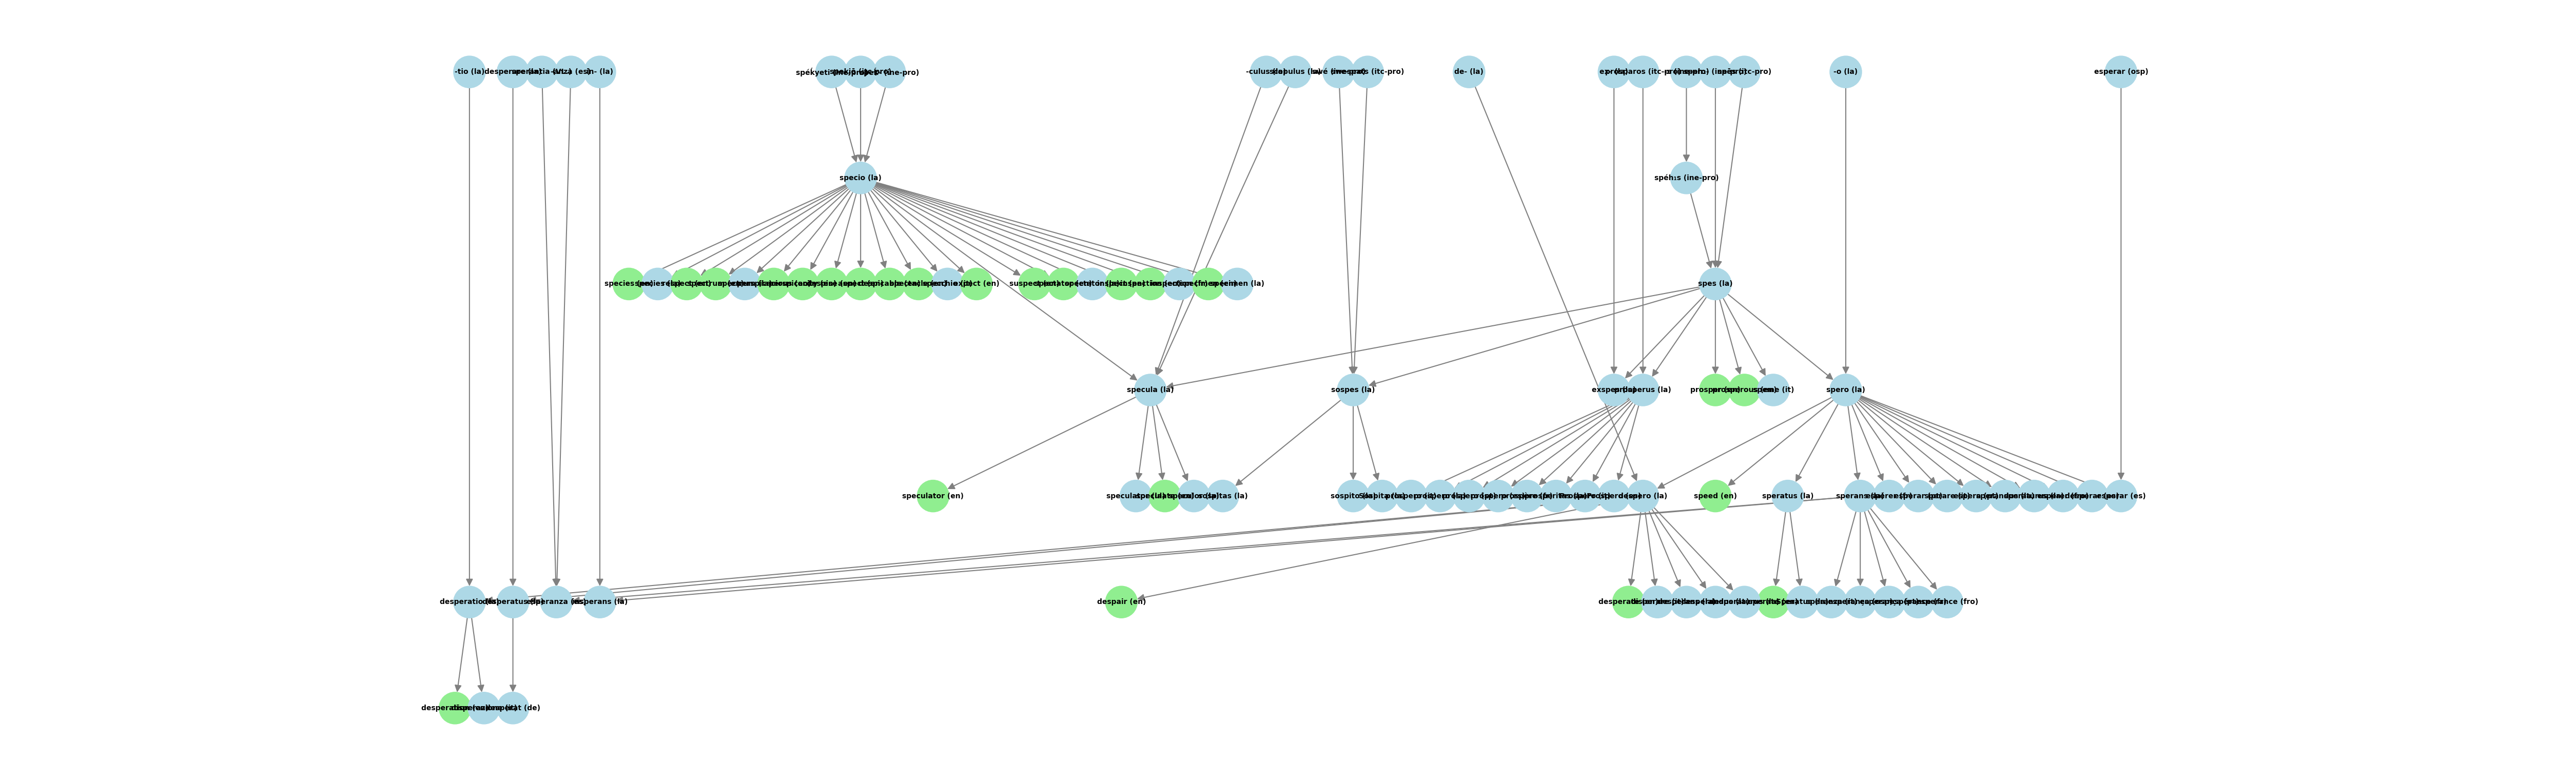

In [ ]:
def graph_sugiyama_improved(G):
    import networkx as nx
    import grandalf
    from grandalf.layouts import SugiyamaLayout
    import matplotlib.pyplot as plt
    
    g = grandalf.utils.convert_nextworkx_graph_to_grandalf(G)
    
    class defaultview(object):
        def __init__(self):
            # Increase the default spacing between nodes
            self.w = 50  # Increased from 10
            self.h = 30  # Increased from 10
    
    for v in g.C[0].sV:
        v.view = defaultview()
    
    sug = SugiyamaLayout(g.C[0])
    # Configure layout parameters
    sug.dx = 100  # Horizontal spacing between nodes
    sug.dy = 50   # Vertical spacing between layers
    sug.init_all()
    sug.draw()
    
    # Extract positions and scale them for better visualization
    poses = {v.data: (v.view.xy[0] * 1.5, -v.view.xy[1]) for v in g.C[0].sV}
    
    # Create a larger figure
    plt.figure(figsize=(50, 15))
    
    # Create node color list based on language
    node_colors = []
    for node in G.nodes():
        lang = node.split('(')[1].rstrip(')')
        if lang == 'en':
            node_colors.append('lightgreen')
        else:
            node_colors.append('lightblue')

    # Draw with modified parameters
    nx.draw(G, pos=poses,
           with_labels=True,
           node_size=2000,        # Larger nodes
           node_color=node_colors,
           font_size=10,
           font_weight='bold',
           width=1.5,            # Thicker edges
           edge_color='gray',
           arrows=True,
           arrowsize=20)
    
    plt.margins(x=0.2)  # Add some padding around the graph
    plt.tight_layout()
    plt.show()



C:\Users\conjunct\AppData\Local\Temp\ipykernel_18124\2257465355.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


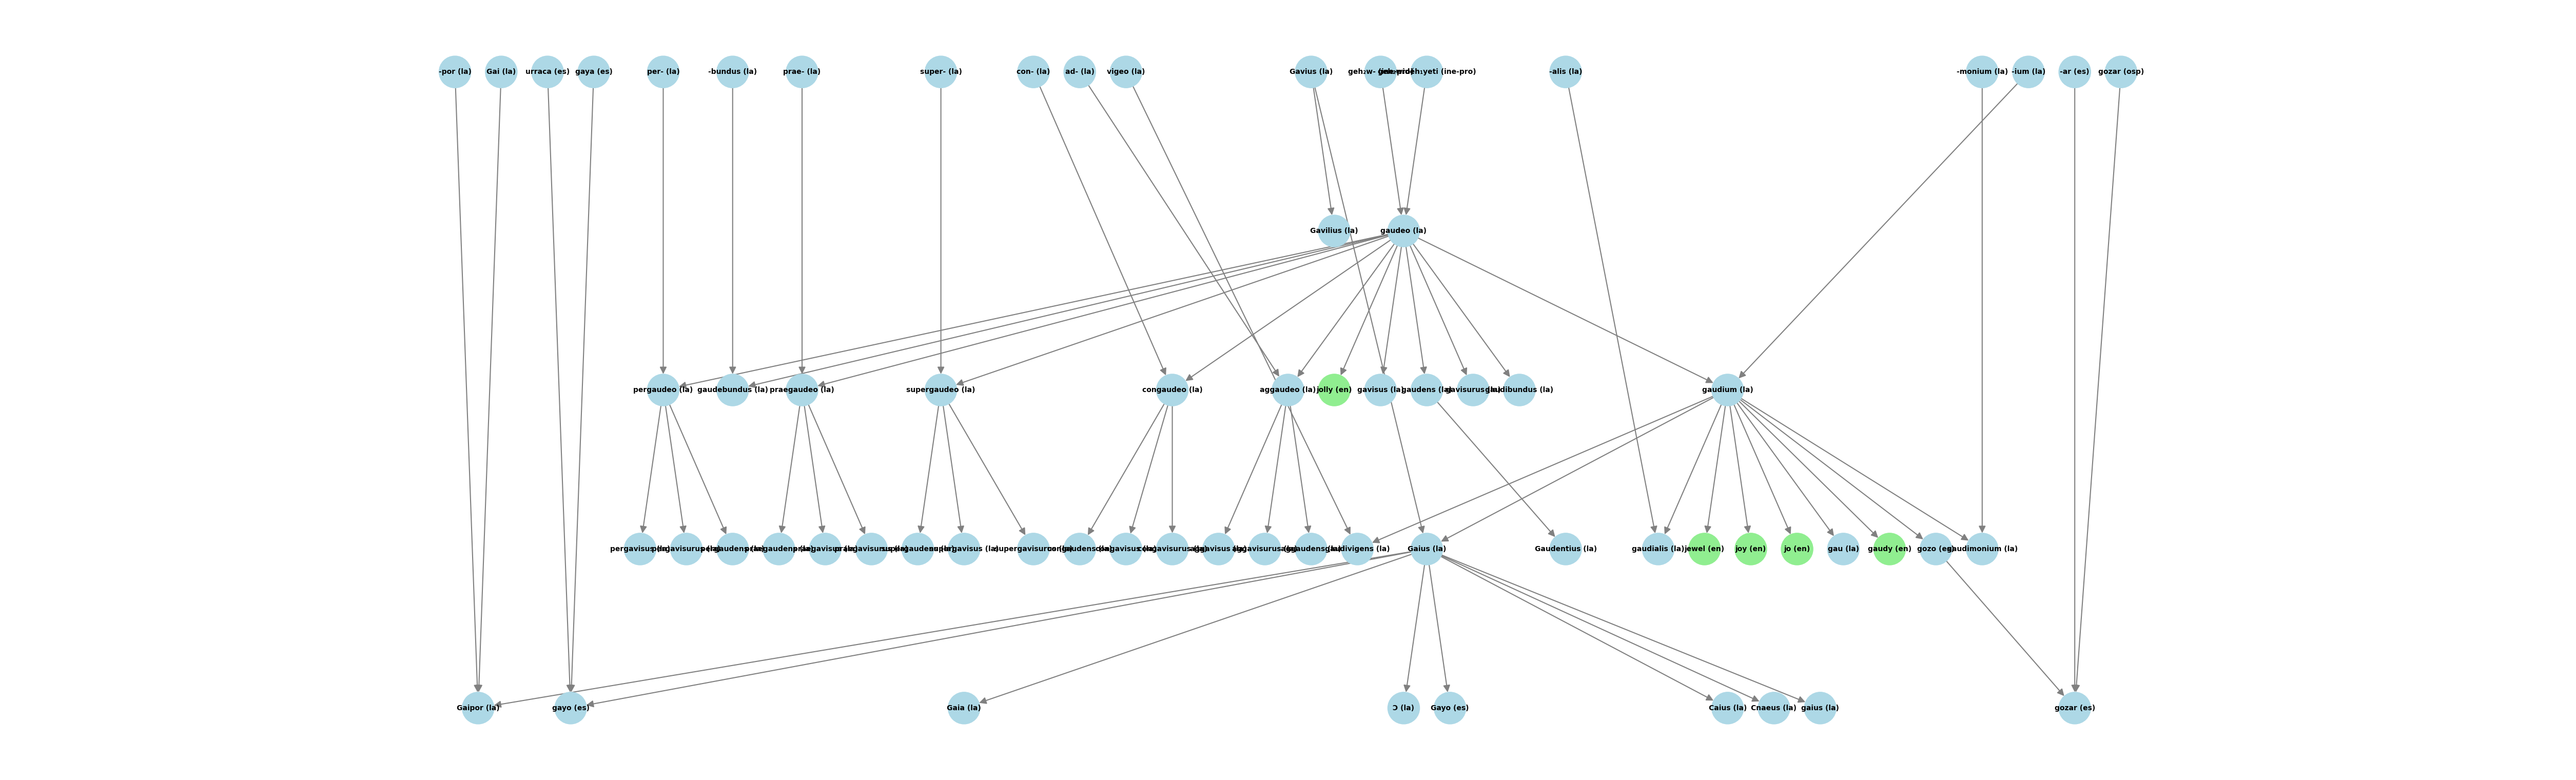

In [340]:
graph = explore_word_graph(edges_df, "gozar", "es", max_vertices=100, lang_rules=lang_rules, word_rules=_word_rules, template_rules=_template_rules)
pruned_graph = prune_leaves(graph, {'en', 'es', 'osp', 'la', 'enm', 'ine-pro', 'gmw-pro'})
graph_sugiyama_improved(pruned_graph)

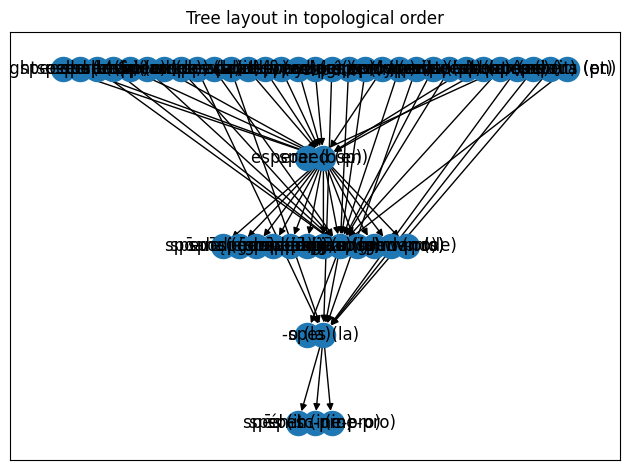

In [274]:
def graph_as_DAG(G):
        
    for layer, nodes in enumerate(reversed(tuple(nx.topological_generations(G)))):
        # `multipartite_layout` expects the layer as a node attribute, so add the
        # numeric layer value as a node attribute
        for node in nodes:
            G.nodes[node]["layer"] = layer

    # Compute the multipartite_layout using the "layer" node attribute
    pos = nx.multipartite_layout(G, subset_key="layer", align='horizontal')

    fig, ax = plt.subplots()
    nx.draw_networkx(G, pos=pos, ax=ax)
    ax.set_title("Tree layout in topological order")
    fig.tight_layout()
    plt.show()

graph_as_DAG(graph)

In [ ]:
# def create_adjacency_df(edges_df: pl.DataFrame) -> pl.DataFrame:
#     """
#     Convert an edge list dataframe to an adjacency list dataframe.
    
#     Args:
#         edges_df: DataFrame with columns [source_word, source_lang, target_word, target_lang, template_name]
    
#     Returns:
#         DataFrame with columns [word, lang, outgoing, incoming] where outgoing/incoming are lists of vertex indices
#     """
# First create a mapping of (word, lang) to vertex index
unique_vertices = (
    pl.concat([
        edges_df.select(['source_word', 'source_lang', 'source_ety']).rename({
            'source_word': 'word',
            'source_lang': 'lang',
            'source_ety': 'ety_number'
        }),
        edges_df.select(['target_word', 'target_lang']).rename({
            'target_word': 'word',
            'target_lang': 'lang'
        }).with_columns(pl.lit(None).alias('ety_number'))
    ])
    .unique()
    .with_row_index('vertex_id')
)

# Create dictionaries for quick lookups
vertex_to_id = {
    (row['word'], row['lang']): row['vertex_id'] 
    for row in unique_vertices.iter_rows(named=True)
}

# add incoming and outcoming columns to vertices
edge_struct_type = pl.Struct([
    pl.Field("id", pl.Int32),
    pl.Field("name", pl.Utf8)
])


# return pl.DataFrame(vertices)

0it [00:00, ?it/s]


AttributeError: 'dict' object has no attribute '_s'

In [ ]:
outgoing_edges = [list() for _ in range(len(unique_vertices))]
incoming_edges = [list() for _ in range(len(unique_vertices))]

# Create adjacency lists
for source_word, source_lang, source_ety, target_word, target_lang, template_name in tqdm(edges_df.iter_rows(), total=edges_df.height):
    source_id = vertex_to_id[(source_word, source_lang)]
    target_id = vertex_to_id[(target_word, target_lang)]
    
    # Add outgoing edge
    outgoing_edges[source_id].append((target_id, template_name))
    
    # Add incoming edge
    incoming_edges[target_id].append((source_id, template_name))

In [362]:
vertices

vertex_id,word,lang,ety_number,outgoing,incoming
u32,str,str,i64,list[struct[2]],list[struct[2]]
0,"""solcatore""","""it""",0,[],[]
1,"""pli""","""xno""",null,[],[]
2,"""osculation""","""en""",0,[],[]
3,"""Wey""","""en""",null,[],[]
4,"""uncarboxylated""","""en""",0,[],[]
…,…,…,…,…,…
1310063,"""endochitinolysis""","""en""",0,[],[]
1310064,"""enfance""","""fro""",0,[],[]
1310065,"""karuhiruhi""","""en""",0,[],[]


In [364]:
inp = vertices.row(0)
inp[-1].append(None)
vertices.row(0) = inp

SyntaxError: cannot assign to function call here. Maybe you meant '==' instead of '='? (2555695152.py, line 3)